
## NIO and cost






## Inputs



(2, 'i_h2i_rate')

(3, 'i_pci_rate')

(5, 'i_ngi_rate')

(6, 'i_o2_volfract')

(8, 'i_h2_temp')

(9, 'i_hbtemp')

(10, 'i_wind_rt')


## Outputs


* desired output requirements 


(27, 'o_tgt')

(29, 'o_hmt')

(39, 'o_prod_rt')

(40, 'o_fta')

(28, 'o_coke_rt')



In [1]:

## !pip install xgboost
## !pip install onnxmltools
## !pip install onnxruntime
## !pip install pandas
## !pip install scikit-learn
## !pip install matplotlib
## !pip install seaborn
## !pip install mlxtend
## ! pip install skl2onnx



In [2]:


import torch
import numpy as np
import pandas as pd
import sklearn
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import math
import seaborn as sns
import random
import functorch


import torch.optim as optim


from numpy.random import normal
from scipy.stats import norm
import scipy.stats as stats
from numpy import hstack
from numpy import vstack
from numpy import exp
from sklearn.neighbors import KernelDensity

##from typing import Optional

from torch import Tensor


from torch.utils.data import TensorDataset, DataLoader

from mlxtend.plotting import heatmap

## coefficient of determination (R**2)
from sklearn.metrics import r2_score

np.set_printoptions(suppress=True)
torch.set_printoptions(sci_mode=False)

import os, json, time, uuid


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score





In [3]:


import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor, DMatrix, train as train_xgb
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import onnxmltools
from onnxmltools.convert.xgboost.operator_converters.XGBoost import (
    convert_xgboost)
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster


from zipfile import ZipFile
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx import convert_sklearn, to_onnx, update_registered_converter
from skl2onnx.common.shape_calculator import (
    calculate_linear_classifier_output_shapes,
    calculate_linear_regressor_output_shapes)


# Import the ONNX runtime environment
import onnxruntime as rt




/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/onnx_ops.py:159: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  tys = obj.typeStr or ''
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/automation.py:154: UserWarning: OpSchema.FormalParameter.isHomogeneous is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.is_homogeneous instead.
  if getattr(obj, 'isHomogeneous', False):
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/jinja2/environment.py:485: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  return getattr(obj, attribute)


In [4]:

import PDFshapingUtils as PDF_tk


In [5]:

PDFshapingOBJ = PDF_tk.PDFshapingUtils()


In [6]:

PDFshapingOBJ.read_csv_file_with_pandas('CFD.16.2025.csv')


In [7]:

## Ty suggested fix where 0 needs to be 300

PDFshapingOBJ.CFD_raw_data["i_h2_temp"] = PDFshapingOBJ.CFD_raw_data["i_h2_temp"].replace(0, 300)


In [8]:

PDFshapingOBJ.CFD_raw_data


,index,case name,i_h2i_rate,i_pci_rate,i_wpi_rate,i_ngi_rate,i_o2_volfract,i_ng_temp,i_h2_temp,i_hbtemp,...,o_h2o_sollos,o_feo_sollos,o_hm_rt,o_mw_rt,o_wf_rt,o_hm_h2share,o_mw_h2share,o_wf_h2share,o_prod_rt,o_fta
0,1,H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HB...,0,0,0,120,21,300,300,1200,...,20.0,44.9,122.0,264.0,687.0,31.6,26.7,63.5,4050.0,1800.0
1,2,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,18.5,52.6,122.0,265.0,684.0,27.9,23.4,60.6,4060.0,1850.0
2,3,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.6,50.9,123.0,266.0,690.0,27.7,23.5,60.8,4080.0,1850.0
3,4,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.2,124.0,268.0,690.0,27.7,23.2,60.6,4090.0,1850.0
4,5,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.4,124.0,268.0,695.0,27.7,23.2,60.7,4110.0,1850.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,4995,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,18.7,40.3,353.0,763.0,2190.0,34.0,20.5,56.7,11700.0,2380.0
4995,4996,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,18.7,40.7,353.0,763.0,2190.0,33.8,20.4,56.8,11700.0,2310.0
4996,4997,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,19.2,37.5,353.0,763.0,2230.0,33.6,20.4,57.1,11700.0,2380.0
4997,4998,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,17.6,39.8,355.0,768.0,2220.0,34.0,20.0,55.7,11800.0,2310.0


In [9]:

PDFshapingOBJ.print_headers_list()


['index', 'case name', 'i_h2i_rate', 'i_pci_rate', 'i_wpi_rate', 'i_ngi_rate', 'i_o2_volfract', 'i_ng_temp', 'i_h2_temp', 'i_hbtemp', 'i_wind_rt', 'i_blastH2O', 'i_BdnH2O', 'i_sgi_rate', 'i_sgtemp', 'i_sgi_H2COratio', 'i_sgi_ReProRatio', 'o_tuy_velo', 'o_tuy_temp', 'o_burn', 'o_delp', 'o_co_vf', 'o_co2_vf', 'o_h2_vf', 'o_n2_vf', 'o_co_util', 'o_h2_util', 'o_tgt', 'o_coke_rt', 'o_hmt', 'o_co2_sollos', 'o_h2o_sollos', 'o_feo_sollos', 'o_hm_rt', 'o_mw_rt', 'o_wf_rt', 'o_hm_h2share', 'o_mw_h2share', 'o_wf_h2share', 'o_prod_rt', 'o_fta']
41
(0, 'index')
(1, 'case name')
(2, 'i_h2i_rate')
(3, 'i_pci_rate')
(4, 'i_wpi_rate')
(5, 'i_ngi_rate')
(6, 'i_o2_volfract')
(7, 'i_ng_temp')
(8, 'i_h2_temp')
(9, 'i_hbtemp')
(10, 'i_wind_rt')
(11, 'i_blastH2O')
(12, 'i_BdnH2O')
(13, 'i_sgi_rate')
(14, 'i_sgtemp')
(15, 'i_sgi_H2COratio')
(16, 'i_sgi_ReProRatio')
(17, 'o_tuy_velo')
(18, 'o_tuy_temp')
(19, 'o_burn')
(20, 'o_delp')
(21, 'o_co_vf')
(22, 'o_co2_vf')
(23, 'o_h2_vf')
(24, 'o_n2_vf')
(25, 'o_co_ut

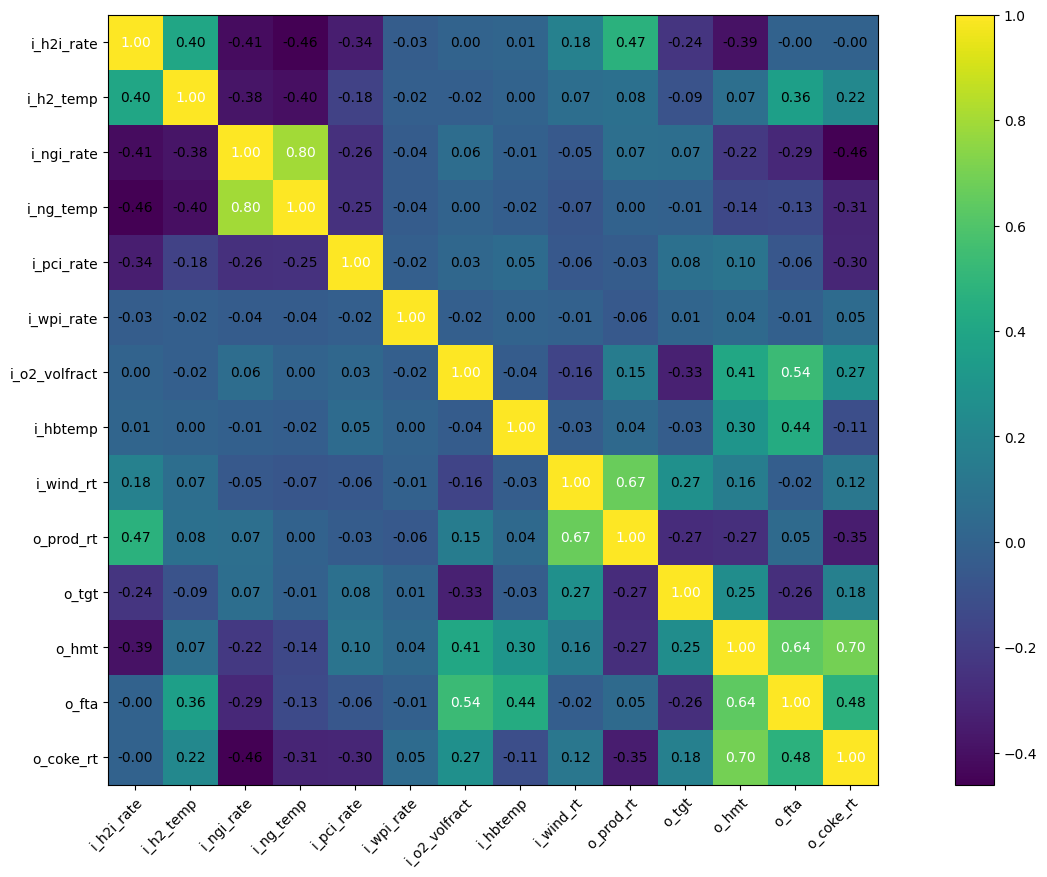

In [10]:


PDFshapingOBJ.list_of_selected_column_names = ['i_h2i_rate','i_h2_temp','i_ngi_rate','i_ng_temp','i_pci_rate',
                    'i_wpi_rate','i_o2_volfract',
                    'i_hbtemp','i_wind_rt','o_prod_rt', 'o_tgt', 'o_hmt','o_fta', 'o_coke_rt']



PDFshapingOBJ.print_correlation_coefficients()


In [11]:

PDFshapingOBJ.convert_pd_data_to_numpy()


[[1
  'H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-7_SGI-0_SGT-0_SGC_0 '
  0 ... 63.5 4050.0 1800.0]
 [2
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-1_SGI-0_SGT-0_SGC_0 '
  0 ... 60.6 4060.0 1850.0]
 [3
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  0 ... 60.8 4080.0 1850.0]
 ...
 [4997
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1600_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 57.1 11700.0 2380.0]
 [4998
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-3_SGI-0_SGT-0_SGC_0 '
  30 ... 55.7 11800.0 2310.0]
 [4999
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 56.2 11800.0 2310.0]]
(4999, 41)


In [12]:

PDFshapingOBJ.gen_X_y_for_selected_indeces(  
                   inputs = [  2, 3, 5, 6, 8, 9, 10   ] , 
                   outputs= [ 27, 29, 39, 40, 28 ]   
)


## inputs = [ 2, 3, 5, 6, 8, 9, 10  ]          ## the full 7



7
5


In [13]:

print(PDFshapingOBJ.X.shape)
print(PDFshapingOBJ.y.shape)


(4999, 7)
(4999, 5)


In [14]:

PDFshapingOBJ.random_seed = int( random.random() * 100  )         ## defautl is 42


In [15]:

PDFshapingOBJ.split_np_data_train_test(selected_test_size=0.2)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [16]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [17]:

'''


from sklearn.decomposition import PCA

# Instantiate PCA to reduce to 4 components
pca = PCA(n_components=4)

# Fit on training data and transform both train and test
X_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)
X_test_pca  = pca.transform(PDFshapingOBJ.X_test)

# Replace the original inputs with PCA-reduced versions
PDFshapingOBJ.X_train = X_train_pca
PDFshapingOBJ.X_test  = X_test_pca


'''


'\n\n\nfrom sklearn.decomposition import PCA\n\n# Instantiate PCA to reduce to 4 components\npca = PCA(n_components=4)\n\n# Fit on training data and transform both train and test\nX_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)\nX_test_pca  = pca.transform(PDFshapingOBJ.X_test)\n\n# Replace the original inputs with PCA-reduced versions\nPDFshapingOBJ.X_train = X_train_pca\nPDFshapingOBJ.X_test  = X_test_pca\n\n\n'

In [18]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [19]:

PDFshapingOBJ.convert_dataset_from_np_to_torch()


In [20]:

PDFshapingOBJ.standardize_X_scales()
PDFshapingOBJ.standardize_y_scales()


In [21]:


PDFshapingOBJ.gen_Dataloader_train()

PDFshapingOBJ.train_dl



## Model Forward ( 7x4 )


In [22]:

n_inputs  = 7     ## 7
n_outputs = 5




#############################################################
##   F1      plus       F2
## Linear     +      Nonlinear

class F1plusF2_SIO_Forward(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations,  device='cuda'):
        super().__init__()
        self.device = device
        
        ## self.x_means      = x_means
        ## self.x_deviations = x_deviations
        ## self.y_means      = y_means
        ## self.y_deviations = y_deviations
        
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)
        
        
        
        ## F1
        self.f1_linear1 = nn.Linear(n_inputs, n_outputs)       
        
        ## F2
        self.f2_linear1 = nn.Linear(n_inputs, 10)
        self.f2_act1    = nn.Sigmoid()                    ## Tanh()                       
        self.f2_linear2 = nn.Linear(10, n_outputs)       
        self.f2_dropout = nn.Dropout(0.25)
        
        # Move model to device
        self.to(self.device)
        
        
    ## perform inference
    def forward(self, x):
        x = x.to(self.device)
        x = (x - self.x_means) / self.x_deviations
        
        ## F1
        f1 = self.f1_linear1(x)
        
        ## F2
        f2 = self.f2_linear1(x)
        f2 = self.f2_act1(f2)
        f2 = self.f2_dropout(f2)
        f2 = self.f2_linear2(f2)
        
        
        y_scaled   = f1 + f2
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        ##   y_descaled = torch.clamp(  y_descaled, min=0.0  )
        
        return y_descaled, y_scaled
    




In [23]:

n_inputs  = 7    ## 7
n_outputs = 5





    
class ResidualNet_Forward(nn.Module):
    def __init__(self, x_means, x_deviations, y_means, y_deviations, dropout_rate=0.1, device='cuda'):
        
        super().__init__()
        self.device = device
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)

     
        self.fc1  = nn.Linear(n_inputs, 64)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(64, 64)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(64, n_outputs)

        # If input_dim ≠ 64, project for residual addition
        self.input_proj = nn.Linear(n_inputs, 64) if n_inputs != 64 else nn.Identity()
        
        # Move model to device
        self.to(self.device)
        

    def forward(self, x):
        x  = x.to(self.device)
        x  = (x - self.x_means) / self.x_deviations
        x0 = self.input_proj(x)
        x1 = self.dropout1(self.act1(self.fc1(x)))
        x2 = self.dropout2(self.act2(self.fc2(x1)))
        x_res = x2 + x0
        y_scaled = self.fc3(x_res)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    

    


In [24]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## model_Forward     = F1plusF2_SIO_Forward(

model_Forward     =     F1plusF2_SIO_Forward(
                         PDFshapingOBJ.x_means, 
                         PDFshapingOBJ.x_deviations, 
                         PDFshapingOBJ.y_means, 
                         PDFshapingOBJ.y_deviations,
                         device=device  # pass device into the model
    
)

optimizer = optim.Adam(model_Forward.parameters(), lr=0.001)
loss_fn   = nn.MSELoss()



In [25]:

model_Forward.train()

for epoch in range(1000):
    for xb, yb in PDFshapingOBJ.train_dl:
        
        xb = xb.to(model_Forward.device)
        yb = yb.to(model_Forward.device)
        
        optimizer.zero_grad()
        pred_descaled, pred_scaled = model_Forward(xb)
        
        loss = loss_fn(pred_scaled, yb)
        loss.backward()
        optimizer.step()
    if epoch % 100 == 0:
        print(epoch, ".....", loss.item() ) 
    



0 ..... 0.9673017263412476
100 ..... 0.45151132345199585
200 ..... 0.6566760540008545
300 ..... 0.4589962661266327
400 ..... 0.3158693015575409
500 ..... 0.15476171672344208
600 ..... 0.18623968958854675
700 ..... 0.2567961513996124
800 ..... 0.22421804070472717
900 ..... 0.1795848309993744


In [26]:

print("=== SANITY CHECK: SCALING ===")
print("y_means:", PDFshapingOBJ.y_means)
print("y_deviations:", PDFshapingOBJ.y_deviations)

print("===============================================")

print("x_means:", PDFshapingOBJ.x_means)
print("x_deviations:", PDFshapingOBJ.x_deviations)


=== SANITY CHECK: SCALING ===
y_means: tensor([[  97.8933, 1299.7932, 8433.2725, 2307.0227,  417.4134]])
y_deviations: tensor([[  50.6489,  526.4135, 1511.4033,  212.1334,   49.8215]])
x_means: tensor([[  12.4681,   18.6659,   41.3181,   25.6294,  414.1786, 1438.6776,
          198.4396]])
x_deviations: tensor([[ 15.1873,  45.3873,  46.5261,   3.3146, 269.6812, 157.9124,  26.6412]])


In [27]:

print(PDFshapingOBJ.y_means -  PDFshapingOBJ.y_deviations)
print(PDFshapingOBJ.y_means +  PDFshapingOBJ.y_deviations)


tensor([[  47.2444,  773.3797, 6921.8691, 2094.8892,  367.5920]])
tensor([[ 148.5422, 1826.2068, 9944.6758, 2519.1562,  467.2349]])


In [28]:

print(PDFshapingOBJ.x_means -  PDFshapingOBJ.x_deviations)
print(PDFshapingOBJ.x_means +  PDFshapingOBJ.x_deviations)


tensor([[  -2.7192,  -26.7213,   -5.2081,   22.3148,  144.4974, 1280.7651,
          171.7985]])
tensor([[  27.6554,   64.0532,   87.8442,   28.9440,  683.8597, 1596.5901,
          225.0807]])


In [29]:

import numpy as np
from numpy.linalg import norm

# --- distance function ---
def euclid(a, b):
    return norm(a - b)



## Now add Costs


In [30]:

def wrapped_model(x):
    y_descaled, _ = model_Forward(x)
    return y_descaled  


In [31]:

price_real = np.array([4.0, 1.0, 0.5, 0.0, 0.0, 0.0, 0.0])

## price_latent = pca.components_ @ price_real

price_real = torch.tensor(price_real, dtype=torch.float32)


for p in model_Forward.parameters():
    p.requires_grad = False


In [32]:



def solve_minimum_norm_update(x0, target_y):

    x = x0.detach().clone().requires_grad_(True)

    current_y = wrapped_model(x)

    ## lambda_cost = 0.01   ## this gave 86% percent of cases improvement
    lambda_cost = 0.001
    
    current_y = (current_y - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations
    target_y   = (target_y - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations
    
    loss_main   = torch.sum( (current_y - target_y)**2 )
    
    
    loss_cost   = lambda_cost *  torch.dot(price_real, x)
    
    loss        = loss_main + loss_cost

    loss.backward()

    ## delta_x = -0.01 * x.grad
    learning_rate = -0.001      ## -1e-5
    delta_x = learning_rate * x.grad
    delta_x = delta_x.view_as(  x0  )

    return delta_x


In [33]:



x_starting_point = torch.tensor(   PDFshapingOBJ.X_test[0]   )    ## starting point

dist_method_A = []
cost_diffs    = [] 
cost_diff     = 0

percent_diffs = []
percent_diff  = 0 


for i in range(  1, PDFshapingOBJ.X_test.shape[0]  ):
    
    target_y  = torch.tensor( PDFshapingOBJ.y_test[i]   )    ## what you want y ?
    x_real    = torch.tensor( PDFshapingOBJ.X_test[i]   )    ## real x
    
    x_temp    = x_starting_point
    
    for j in range(1000):
        
        delta_x  = solve_minimum_norm_update( x_temp, target_y )
        x_temp   = x_temp + delta_x
        
        # ---- compute cost at this iteration ----
        x_temp_np   = x_temp.detach().numpy()
        x_temp_real = x_temp_np

        x_temp_real = np.maximum(x_temp_real, 0.0)  # enforce physical constraint

        cost = np.dot(price_real, x_temp_real)
        
        x_real_np         = x_real.detach().numpy()
        x_real_np_sol     = x_real_np  
        cost_real         = np.dot(price_real, x_real_np_sol)
       
        if j % 200 == 0:           ## 20
            print(f"iteration {j} cost: {cost}...H2, PCI, NGI:", x_temp_real[:3] )
            print("real cost       :", cost_real)
        
   
        cost_diff = cost - cost_real
        if cost_real > 0:
            percent_diff = cost_diff / cost_real
            percent_diffs.append(percent_diff)
        
    ## percent_diffs.append( percent_diff  )
          
    cost_diffs.append(       cost_diff  )
      
        
    x_new             = x_temp  
    
    x_new_np          =  x_new.detach().numpy()
    x_real_np         = x_real.detach().numpy()
    
    x_new_solution    =  x_new_np   
    x_real_np_sol     =  x_real_np  
    
    
    # enforce physical constraint
    x_new_solution = np.maximum(x_new_solution, 0.0)
    x_real_np_sol  = np.maximum(x_real_np_sol,  0.0)
    
    
    the_cols = "    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    
    
    print("...")
    print("...")
    print("...")
    print( the_cols )
    print( "pred" )
    print( x_new_solution )
    print( "real" )
    print( x_real_np_sol )
    print("...")
    print( "y pred" )
    print( wrapped_model(torch.from_numpy(x_new_solution))   )
    print( "y real" )
    print( wrapped_model(torch.from_numpy(x_real_np_sol))   )
    
    dist_method_A.append( euclid(x_new_np, x_real_np) )
    
    print(i)
    print('********************************')




iteration 0 cost: 35.00139236450195...H2, PCI, NGI: [ 0.00031511  0.00009191 70.00008   ]
real cost       : 150.0
iteration 200 cost: 35.32673645019531...H2, PCI, NGI: [ 0.07528909  0.01831878 70.01453   ]
real cost       : 150.0
iteration 400 cost: 35.63422393798828...H2, PCI, NGI: [ 0.14604875  0.03569147 70.02867   ]
real cost       : 150.0
iteration 600 cost: 35.942893981933594...H2, PCI, NGI: [ 0.21709226  0.05311752 70.042816  ]
real cost       : 150.0
iteration 800 cost: 36.24904251098633...H2, PCI, NGI: [ 0.287599    0.07034915 70.056595  ]
real cost       : 150.0
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   0.35577792    0.08704021   70.06979      23.64903     300.
 1448.          195.02177   ]
real
[   0.  150.    0.   21.  300. 1600.  230.]
...
y pred
tensor([[ 125.7771, 1402.8231, 7318.3564, 2238.0552,  423.2363]])
y real
tensor([[ 146.5147, 1404.7943, 9171.8516, 2185.7117,  358.9830]])
1
******************

iteration 800 cost: 36.69186782836914...H2, PCI, NGI: [ 0.40191457  0.07772805 70.01296   ]
real cost       : 105.0
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   0.48859495    0.09474819   70.0168       24.621878    300.
 1448.          195.01328   ]
real
[   0.   60.   90.   30.  300. 1480.  195.]
...
y pred
tensor([[ 118.0222, 1469.2815, 7492.8623, 2277.1008,  426.5815]])
y real
tensor([[  84.1819, 1519.4883, 9171.6465, 2391.2910,  382.6283]])
9
********************************
iteration 0 cost: 35.004112243652344...H2, PCI, NGI: [ 0.00098034  0.00017287 70.00004   ]
real cost       : 200.0
iteration 200 cost: 35.643985748291016...H2, PCI, NGI: [ 0.15357587  0.02568071 70.008     ]
real cost       : 200.0
iteration 400 cost: 36.29106903076172...H2, PCI, NGI: [ 0.30782458  0.05177593 70.01599   ]
real cost       : 200.0
iteration 600 cost: 36.87540817260742...H2, PCI, NGI: [ 0.44721392  0.0745853  70.02393   ]
real cos

iteration 400 cost: 36.29117202758789...H2, PCI, NGI: [ 0.30444822  0.06066323 70.02543   ]
real cost       : 60.0
iteration 600 cost: 36.88933563232422...H2, PCI, NGI: [ 0.44525632  0.08924343 70.03813   ]
real cost       : 60.0
iteration 800 cost: 37.4917106628418...H2, PCI, NGI: [ 0.58708555  0.11803225 70.050674  ]
real cost       : 60.0
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   0.7204811     0.14494658   70.06346      24.094036    300.
 1448.          194.96358   ]
real
[   0.    0.  120.   24.  300. 1600.  195.]
...
y pred
tensor([[ 119.2342, 1408.4548, 7479.2490, 2259.4658,  422.9058]])
y real
tensor([[ 123.9809, 1313.1744, 7979.9956, 2211.2446,  370.7455]])
18
********************************
iteration 0 cost: 35.004329681396484...H2, PCI, NGI: [ 0.00101837  0.00020442 70.00011   ]
real cost       : 45.0
iteration 200 cost: 35.68020248413086...H2, PCI, NGI: [ 0.15956467  0.03210534 70.01968   ]
real cost    

iteration 200 cost: 35.541324615478516...H2, PCI, NGI: [ 0.12864214  0.02163763 70.01024   ]
real cost       : 120.0
iteration 400 cost: 36.06997299194336...H2, PCI, NGI: [ 0.25421202  0.04327656 70.0197    ]
real cost       : 120.0
iteration 600 cost: 36.56400680541992...H2, PCI, NGI: [ 0.37164843  0.06301661 70.02879   ]
real cost       : 120.0
iteration 800 cost: 37.06613540649414...H2, PCI, NGI: [ 0.491011    0.08325633 70.037674  ]
real cost       : 120.0
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   0.6053634     0.10198896   70.04612      23.582586    300.
 1448.          194.89856   ]
real
[  30.    0.    0.   24.  600. 1200.  160.]
...
y pred
tensor([[ 123.5364, 1376.1583, 7376.7695, 2239.2915,  421.4115]])
y real
tensor([[  72.5116,  535.8826, 7052.4863, 2123.0437,  424.1617]])
27
********************************
iteration 0 cost: 35.001033782958984...H2, PCI, NGI: [ 0.00024759  0.00004406 70.        ]
real co

...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   0.84723246    0.17210521   70.11259      23.50768     300.
 1448.          195.03601   ]
real
[  50.    0.    0.   21.  300. 1600.  230.]
...
y pred
tensor([[ 124.5375, 1360.1277, 7366.8740, 2221.9062,  419.8586]])
y real
tensor([[   99.7374,   568.2522, 10756.7607,  2118.0776,   373.9580]])
35
********************************
iteration 0 cost: 35.00102996826172...H2, PCI, NGI: [ 0.00023254  0.00005755 70.000084  ]
real cost       : 175.0
iteration 200 cost: 35.609066009521484...H2, PCI, NGI: [ 0.14257924  0.03017393 70.01715   ]
real cost       : 175.0
iteration 400 cost: 36.2105827331543...H2, PCI, NGI: [ 0.28352103  0.05956019 70.033875  ]
real cost       : 175.0
iteration 600 cost: 36.78691482543945...H2, PCI, NGI: [ 0.41852373  0.08766562 70.05031   ]
real cost       : 175.0
iteration 800 cost: 37.357059478759766...H2, PCI, NGI: [ 0.55209994  0.11550894 70.0663    ]
rea

...

iteration 200 cost: 35.30418014526367...H2, PCI, NGI: [ 0.07379065  0.01045554 69.99712   ]
real cost       : 120.0
iteration 400 cost: 35.59279251098633...H2, PCI, NGI: [ 0.1437834   0.02040473 69.99451   ]
real cost       : 120.0
iteration 600 cost: 35.8818359375...H2, PCI, NGI: [ 0.21392806  0.0302042  69.99184   ]
real cost       : 120.0
iteration 800 cost: 36.14114761352539...H2, PCI, NGI: [ 0.27688622  0.03891659 69.98937   ]
real cost       : 120.0
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   0.33965203    0.04747536   69.98713      24.559412    300.
 1448.          195.00693   ]
real
[  30.    0.    0.   27.  300. 1448.  195.]
...
y pred
tensor([[ 119.2362, 1472.9108, 7458.4937, 2275.9199,  427.1517]])
y real
tensor([[  75.0699, 1221.1334, 8800.4971, 2319.9465,  440.4772]])
963
********************************
iteration 0 cost: 35.003509521484375...H2, PCI, NGI: [ 0.00084008  0.00014428 70.00001   ]
real cost  

iteration 400 cost: 36.707767486572266...H2, PCI, NGI: [ 0.4004691   0.08195105 70.04788   ]
real cost       : 60.0
iteration 600 cost: 37.48158264160156...H2, PCI, NGI: [ 0.58173925  0.11920554 70.07084   ]
real cost       : 60.0
iteration 800 cost: 38.25123596191406...H2, PCI, NGI: [ 0.7619963   0.15654728 70.09341   ]
real cost       : 60.0
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   0.943115      0.19398567   70.11545      23.49822     300.
 1448.          194.9272    ]
real
[   0.    0.  120.   21.  300. 1448.  195.]
...
y pred
tensor([[ 111.0096, 1279.3993, 7693.5703, 2237.0908,  412.1268]])
y real
tensor([[ 158.0317,  955.1023, 7231.3574, 2005.2712,  370.0010]])
971
********************************
iteration 0 cost: 34.999961853027344...H2, PCI, NGI: [ 0.       0.      69.99992]
real cost       : 35.0
iteration 200 cost: 34.993995666503906...H2, PCI, NGI: [ 0.       0.      69.98799]
real cost       : 35.0
iter

...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   0.49471343    0.11183445   70.05736      24.156124    300.
 1448.          195.03821   ]
real
[   0.  160.   40.   24.  300. 1480.  230.]
...
y pred
tensor([[ 121.2754, 1433.2356, 7423.7822, 2257.7781,  424.5260]])
y real
tensor([[  132.0359,  1218.7971, 10042.4648,  2133.9312,   331.0789]])
979
********************************
iteration 0 cost: 35.00086975097656...H2, PCI, NGI: [ 0.0002027   0.00002901 70.00006   ]
real cost       : 80.0
iteration 200 cost: 35.3436164855957...H2, PCI, NGI: [ 0.08001775  0.01605653 70.01498   ]
real cost       : 80.0
iteration 400 cost: 35.67755126953125...H2, PCI, NGI: [ 0.15789095  0.03147897 70.029015  ]
real cost       : 80.0
iteration 600 cost: 35.9976806640625...H2, PCI, NGI: [ 0.2325967   0.04602173 70.04254   ]
real cost       : 80.0
iteration 800 cost: 36.318992614746094...H2, PCI, NGI: [ 0.30765122  0.06064966 70.05547   ]
real cos

iteration 200 cost: 35.00120162963867...H2, PCI, NGI: [ 0.      0.     70.0024]
real cost       : 50.0
iteration 400 cost: 35.002140045166016...H2, PCI, NGI: [ 0.       0.      70.00428]
real cost       : 50.0
iteration 600 cost: 35.003257751464844...H2, PCI, NGI: [ 0.        0.       70.006516]
real cost       : 50.0
iteration 800 cost: 35.003684997558594...H2, PCI, NGI: [ 0.       0.      70.00737]
real cost       : 50.0
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   0.          0.         70.009476   22.476992  300.       1448.
  195.05717 ]
real
[   0.    0.  100.   24.  300. 1200.  195.]
...
y pred
tensor([[ 127.0309, 1310.0697, 7270.3945, 2195.1003,  413.6902]])
y real
tensor([[ 132.3590, 1019.3573, 7424.0513, 1988.9611,  399.4417]])
988
********************************
iteration 0 cost: 35.002777099609375...H2, PCI, NGI: [ 0.0006497   0.00014592 70.00006   ]
real cost       : 180.0
iteration 200 cost: 35.424869537

iteration 800 cost: 34.973358154296875...H2, PCI, NGI: [ 0.       0.      69.94672]
real cost       : 80.0
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[   0.          0.         69.93425    24.513895  300.       1448.
  195.00275 ]
real
[  20.    0.    0.   30. 1200. 1200.  160.]
...
y pred
tensor([[ 121.9750, 1480.3148, 7376.8882, 2266.8210,  428.7005]])
y real
tensor([[  55.1966, 1454.8440, 6980.2041, 2554.1123,  480.1366]])
996
********************************
iteration 0 cost: 35.001956939697266...H2, PCI, NGI: [ 0.00045879  0.0000721  70.0001    ]
real cost       : 160.0
iteration 200 cost: 35.59870529174805...H2, PCI, NGI: [ 0.14048961  0.02709826 70.019295  ]
real cost       : 160.0
iteration 400 cost: 36.183570861816406...H2, PCI, NGI: [ 0.27783537  0.05335438 70.03775   ]
real cost       : 160.0
iteration 600 cost: 36.78505325317383...H2, PCI, NGI: [ 0.41910926  0.08070238 70.055824  ]
real cost       : 160.0
ite

In [34]:

avg_A = np.mean(dist_method_A)


print("Average Euclidean Distance:")
print("Method A:", avg_A)


Average Euclidean Distance:
Method A: 251.95517


In [35]:

print("average cost diff:",    np.mean(cost_diffs))
print("average percent diff:", np.mean(percent_diffs)*100, "%")


average cost diff: -53.190918
average percent diff: -40.26825726032257 %


In [36]:

better = np.sum(np.array(cost_diffs) < 0)
total  = len(cost_diffs)

print("solver cheaper in:", better/total*100, "% of cases")


solver cheaper in: 86.28628628628628 % of cases
